<a href="https://colab.research.google.com/github/supsi-dacd-isaac/teaching/blob/main/2021SmartGrids/L04_final_project_introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Simulatore di impianto fotovoltaico
Questo primo esempio è un **semplice simulatore di impianto fotovoltaico**, che simula la produzione di un impianto fotovoltaico non ombreggiato, partendo da una posizione e da un file meteo che contiene T e GHI. Useremo la [libreria pvlib](https://pvlib-python.readthedocs.io/) per aiutarci con alcuni calcoli. Si tratta di una libreria di simulazione fotovoltaica molto potente che può essere utilizzata per simulare in dettaglio gli impianti fotovoltaici. Per semplicità, qui non la utilizzeremo al massimo delle sue capacità.

In [23]:
%%capture
!pip install pvlib
import pvlib
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

Per prima cosa, carichiamo il file **meteo.csv** in un dataframe pandas

In [24]:
!gdown 1Psvmk5z3zlB8YBmK5PR0vd4J0RLirgKG # download meteo data from shared gdrive file
meteo = pd.read_csv('meteo.csv', header=0, parse_dates=[0], date_format='%d-%b-%Y %H:%M:%S', index_col=0)

Downloading...
From: https://drive.google.com/uc?id=1Psvmk5z3zlB8YBmK5PR0vd4J0RLirgKG
To: /content/meteo.csv
100% 1.02M/1.02M [00:00<00:00, 57.2MB/s]


Plottiamolo

array([<Axes: xlabel='t'>, <Axes: xlabel='t'>], dtype=object)

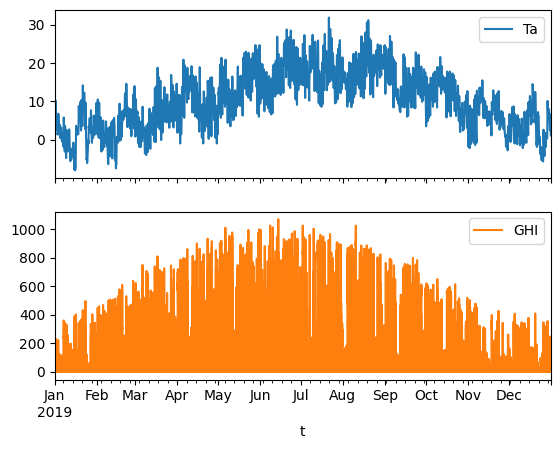

In [25]:
meteo.plot(subplots=True)

Definiamo la posizione e l'orientamento dell'impianto

In [26]:
# location
latitude = 47.03
longitude = 8.296
altitude = 460
location = pvlib.location.Location(latitude, longitude, 'Etc/GMT+1', altitude)

# PV plant
p_module = 300  # potenza del modulo in 300W (1m x 1.7m) (non cambiare)
num_modules = 66  # numero di moduli
tilt = 15
azimuth = 193
albedo = 0.1 # albedo of the ground for ground reflected irradiance

Ora calcoliamo l'irraggiamento sul piano dell'array nel modo seguente:
*   Calcoliamo la posizione del sole in base alla località e all'ora
*   Dividiamo l'irradiazione solare globale (GHI) nelle sue componenti diretta e diffusa
*   E le proiettiamo sul piano dell'array (POA)

In [27]:
sun_pos = location.get_solarposition(meteo.index)
ghi = meteo['GHI']
dni = pvlib.irradiance.dirint(meteo['GHI'], sun_pos['zenith'], sun_pos.index)
dni.fillna(0, inplace=True)
dhi = ghi - np.cos(np.deg2rad(sun_pos['zenith'])) * dni


irr = pvlib.irradiance.get_total_irradiance(tilt, azimuth, sun_pos['zenith'], sun_pos['azimuth'], dni, ghi, dhi,
                                      albedo=albedo, model_perez='allsitescomposite1990')

## Calcoliamo la potenza dell'impianto fotovoltaico con un modello semplificato che tiene conto dell'angolo d'incidenza, della temperatura e dell'efficienza dell'inverter.

### Correggiamo per l'angolo di incidenza
Calcoliamo l'IAM (angle of incidence modifier)

$$ IAM(\theta) = \frac{\tau_\theta}{\tau_0} $$

utilizzando il modello [ASHRAE](https://pvpmc.sandia.gov/modeling-guide/1-weather-design-inputs/shading-soiling-and-reflection-losses/incident-angle-reflection-losses/ashrae-iam-model/)

$$ IAM_B = 1 - b_0 \left( \frac{1}{\cos(\theta_{AOI})} - 1 \right)$$

$IAM_B$: Modificatore dell’angolo di incidenza per il fascio diretto (beam)

$b_0$: Coefficiente empirico che quantifica la perdita angolare

$\theta_{AOI}$: Angolo di incidenza (AOI = Angle of Incidence)

e lo applichiamo solo alla componente diretta dell'irraggiamento
Alla componente diffusa applichiamo un fattore 0.95

In [28]:
b0 = 0.05
aoi = pvlib.irradiance.aoi(tilt, azimuth, sun_pos['zenith'], sun_pos['azimuth'])  # angle of incidence
iam = np.maximum(1 - b0 * (1 / np.cos(np.minimum(np.deg2rad(aoi), np.pi/2)) - 1), 0)
irr['poa_eff'] = iam * irr['poa_direct'] + 0.95 * (irr['poa_diffuse'])

### Correggiamo per la temperatura

Calcoliamo la temperatura della cella utilizzando il [modello Sandia](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.temperature.sapm_cell.html), che si basa su queste due equazioni empiriche:


$$T_{m} = E \cdot \exp (a + b \cdot WS) + T_{a}$$
$$T_{C} = T_{m} + \frac{E}{E_{0}} \Delta T$$

In [29]:
gamma = -0.34 / 100  # power loss as function of temperature
t_nom = 25  # nominal temperature
a=-3.56 #
b=-0.075
deltaT=3
wind_speed=1
i_stc = 1000

t_cell = pvlib.temperature.sapm_cell(irr['poa_global'], meteo['Ta'], wind_speed, a, b, deltaT, irrad_ref=i_stc)
irr['poa_eff_tc'] = irr['poa_eff'] * (1 + gamma * (t_cell - t_nom))

Quindi correggiamo l'efficienza del modulo e dell'inverter in funzione di GHI utilizzando la seguente formula (a bassi irraggiamenti l'efficienza è più bassa):

$$ \eta = k2 + k3 \cdot \log(GHI / GHI_{STC}) +k4 \cdot\log(GHI/GHI_{STC})^2 $$

In [30]:
k2 = 0.942
k3 = -5.02e-2
k4 = -3.77e-2
np.seterr(divide = 'ignore') # disable divide by zero warning
eta = np.maximum(0.1, (k2 + k3 * np.log(irr['poa_eff'] / i_stc) + k4 * np.log(irr['poa_eff'] / i_stc)**2).fillna(0))
np.seterr(divide = 'warn')
irr['poa_eff_tc_li'] = irr['poa_eff_tc'] * eta

Calcoliamo la potenza dell'impianto fotovoltaico

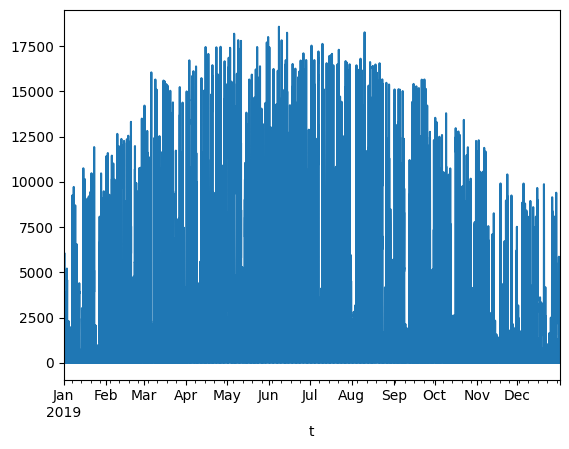

In [31]:
# power of plant in W
p_plant = p_module * irr['poa_eff_tc_li'] / 1000 * num_modules
p_plant.plot()

# calculate the energy of the plant in kWh
e_plant = p_plant / 1000 * (p_plant.index[1]- p_plant.index[0]).seconds / 3600 # W to kWh

# here this is useless
save_path = 'energy_pv.csv'
e_plant.to_csv(save_path, sep=',', date_format='%Y-%m-%dT%H:%M:%S', float_format='%.03f')

# this downloads the csv file onto your local machine
# from google.colab import files
# files.download('energy_pv.csv')

# 2. Esplorazione dei dati di consumo
Nelle celle seguenti, scarichiamo i dati di consumo dagli appartamenti in un dataframe di pandas e li tracciamo


In [32]:
!gdown 1F8rP6NoZiTUsu9nNEMN3suIhStaSCn78
consumption = pd.read_csv('dati_consumo_15min.csv', header=0, parse_dates=[0], date_format='%d/%m/%Y %H:%M', index_col=0)
consumption.head()

Downloading...
From: https://drive.google.com/uc?id=1F8rP6NoZiTUsu9nNEMN3suIhStaSCn78
To: /content/dati_consumo_15min.csv
100% 13.1M/13.1M [00:00<00:00, 85.6MB/s]


,meter_0001,meter_0002,meter_0003,meter_0004,meter_0005,meter_0006,meter_0007,meter_0008,meter_0009,meter_0010,...,meter_0021,meter_0022,meter_0023,meter_0024,meter_0025,meter_0026,meter_0027,meter_0028,meter_0029,meter_0030
time,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:15:00,0.018017,0.020275,0.021447,0.011577,0.009398,0.009164,0.008745,0.007786,0.021154,0.005755,...,0.016487,0.009100,0.018573,0.030718,0.023458,0.024895,0.022042,0.009034,0.018996,0.013450
2019-01-01 00:30:00,0.009959,0.008225,0.012203,0.015851,0.026795,0.017168,0.017885,0.007622,0.010595,0.005710,...,0.007967,0.009185,0.017974,0.028733,0.015230,0.015171,0.012482,0.016341,0.009567,0.038097
2019-01-01 00:45:00,0.009920,0.008091,0.012366,0.017200,0.016013,0.009262,0.008605,0.010487,0.010732,0.005690,...,0.007479,0.009131,0.018131,0.027909,0.015626,0.015120,0.012588,0.040415,0.009668,0.047851
2019-01-01 01:00:00,0.011537,0.008054,0.012329,0.011694,0.009429,0.009246,0.008486,0.014420,0.010446,0.005753,...,0.007439,0.017151,0.036369,0.022211,0.016980,0.019095,0.012292,0.030651,0.009534,0.050035
2019-01-01 01:15:00,0.016851,0.015236,0.022917,0.011671,0.011918,0.009063,0.008548,0.007790,0.013327,0.005644,...,0.011226,0.009225,0.028554,0.022608,0.023549,0.020699,0.022079,0.031388,0.019017,0.048181


Text(0.5, 0, 'total consumption [kWh]')

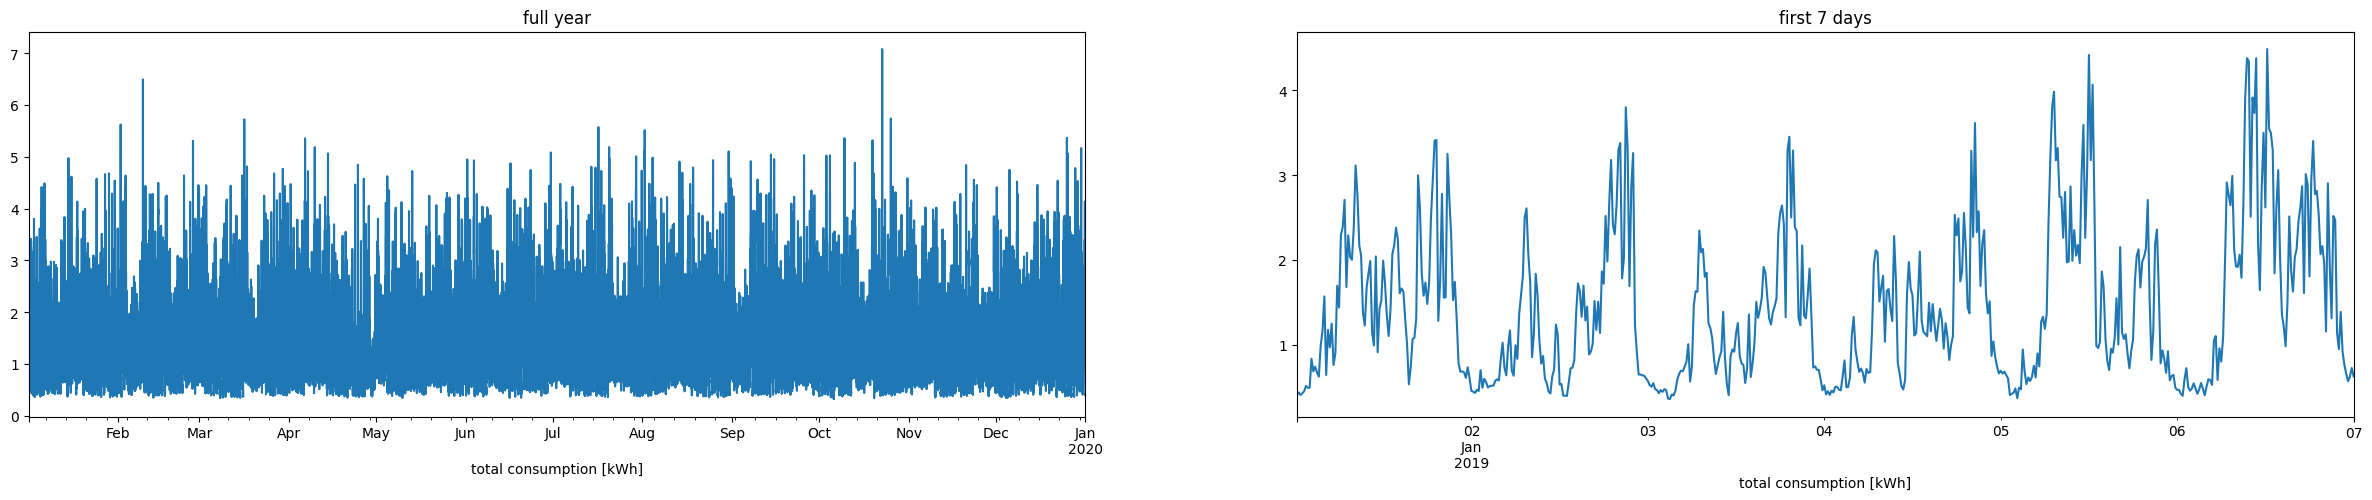

In [33]:
fig, ax = plt.subplots(1,2,figsize=(30,5))
E15 = consumption.sum(axis=1)
E15.plot(ax=ax[0])
ax[0].set_title('full year')
ax[0].set_xlabel('total consumption [kWh]')
E15.iloc[consumption.index<'2019-01-07 00:15:00'].plot(ax=ax[1])
ax[0].set_title('full year')
ax[0].set_xlabel('total consumption [kWh]')
ax[1].set_title('first 7 days')
ax[1].set_xlabel('total consumption [kWh]')

# 3. Stima del ritorno sull'investimento per l'impianto fotovoltaico
Stimiamo il ritorno sull'investimento di un impianto fotovoltaico, dati:
*  Profilo di produzione (calcolato sopra)
*  Costo dell'impianto fotovoltaico
*  Costi di funzionamento e manutenzione
*  Prezzi dell'energia
*  Autoconsumo
*  Costo del capitale
*  Durata prevista dell'impianto fotovoltaico
Per prima cosa installiamo le librerie necessarie e definiamo i parametri


In [34]:
%%capture
!pip install numpy_financial
import numpy_financial as npf  # used to calculate financial figures
o_and_m = 30  # operation and maintenace costs [CHF/kW]
wacc = 0.02  # weighted average cost of capital
life_span = 25
degradation = 0.2  # 20% after 25years

self_consumption = 0.6  # 60%
p_sell = 0.06
p_buy = 0.21
p_pv = p_buy * self_consumption + p_sell * (1 - self_consumption)

plant_size = p_module * num_modules / 1000
plant_cost = 34520

**Calcoliamo la produzione di energia fotovoltaica durante i 25 anni di vita e teniamo conto del degrado** dell'impianto fotovoltaico.
Il degrado totale dopo la vita utile dovrebbe essere del 20%, possiamo calcolare il degrado ad ogni intervallo di tempo utilizzando le seguenti formule:
$$(1-d) = (1-d_m)^{mt}$$
$$d_m = 1-(1-d)^{1/mt}$$
dove $d$ è il degrado totale alla fine della vita, $t$ è la durata in anni e $m$ è il numero di passi all'anno

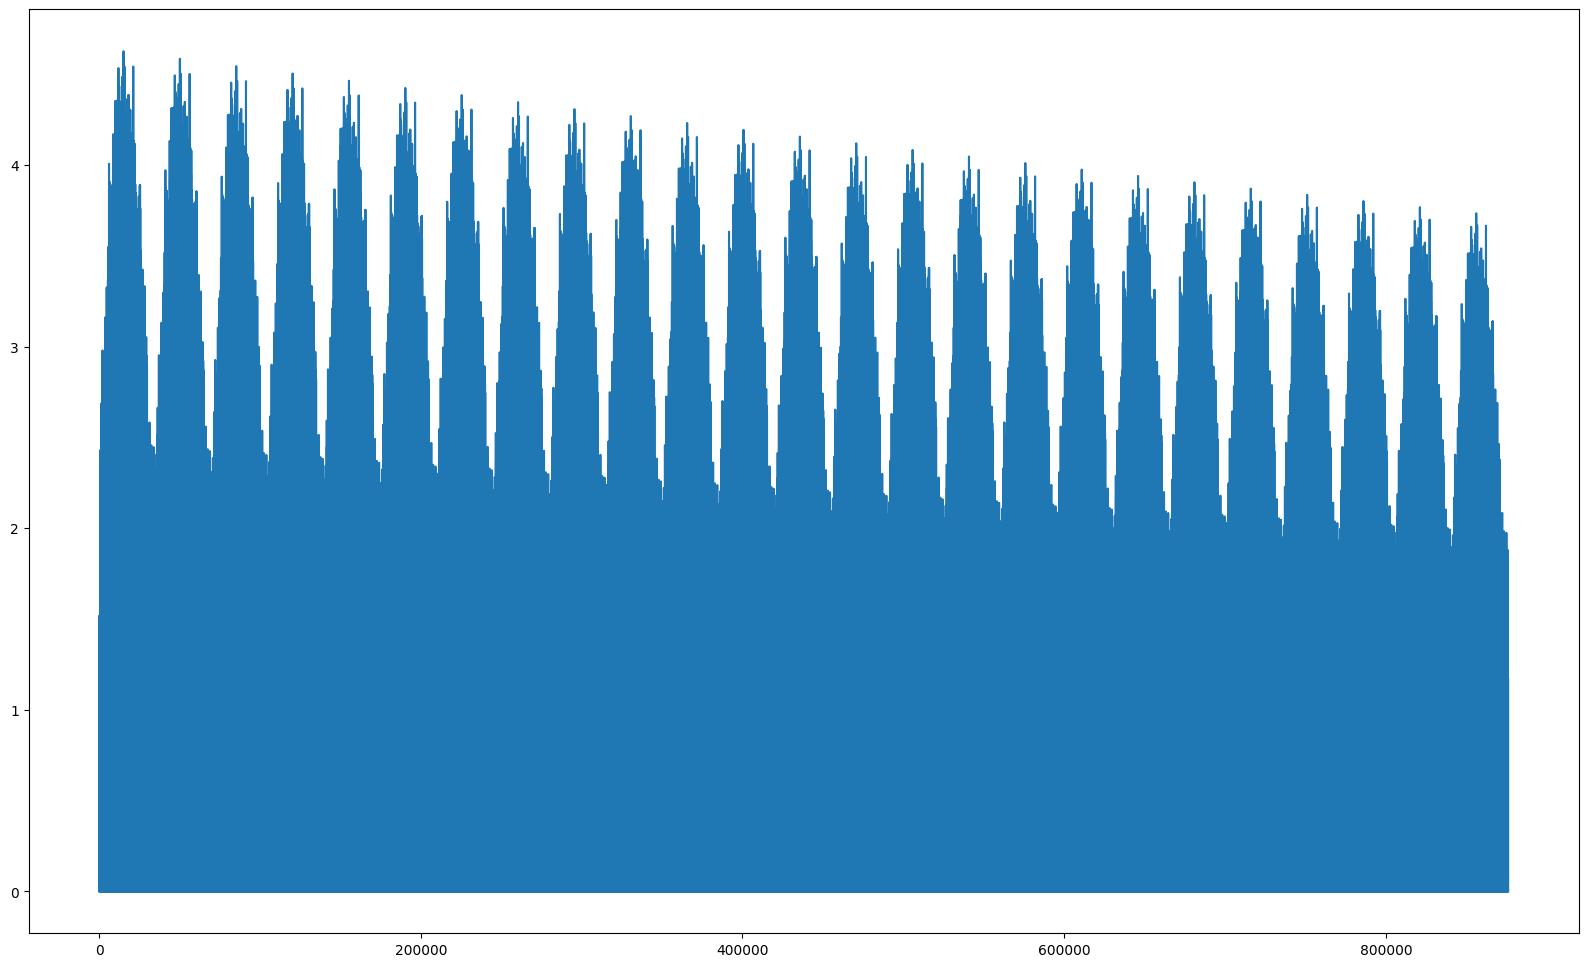

In [35]:
e_ls = np.tile(e_plant, life_span)
d_m = 1 - (1-degradation)**(1/len(e_ls))
eta = (1-d_m)**np.arange(len(e_ls))
e_ls *= eta

plt.figure(figsize=(20,12))
plt.plot(e_ls);

Ora eseguiamo un'analisi finanziaria molto semplicistica per stimare il ritorno sull'investimento.
Innanzitutto, calcoliamo tutti i costi e i ricavi. Quindi calcoliamo il flusso di cassa libero per la durata del sistema fotovoltaico e quindi calcoliamo il valore attuale netto per ogni anno per calcolare dopo quanti anni raggiungiamo una condizione di pareggio. In questa analisi molto semplice, non teniamo conto delle tasse.

**NPV:**
In economia, il valore attuale netto (abbreviato in NPV) è un metodo utilizzato per definire il valore attuale di una serie prevista di flussi di cassa non solo sommandoli nei conti, ma scontandoli sulla base del tasso di rendimento.
$${\mathrm{NPV}} (i, N) = \sum_{t=0}^N \frac{R_t}{(1+i)^t}$$

$R_t$: flusso di cassa netto al tempo t

$i$:	tasso di sconto

$N$:	numero di periodi


**IRR:**
Il tasso interno di rendimento (IRR) è il tasso di sconto che rende il valore attuale netto (NPV) di un progetto pari a zero. In altre parole, è il tasso di rendimento atteso che eguaglia il valore attuale dei flussi di cassa futuri al costo iniziale dell'investimento.

$${\mathrm{NPV}} (IRR, N) = 0$$


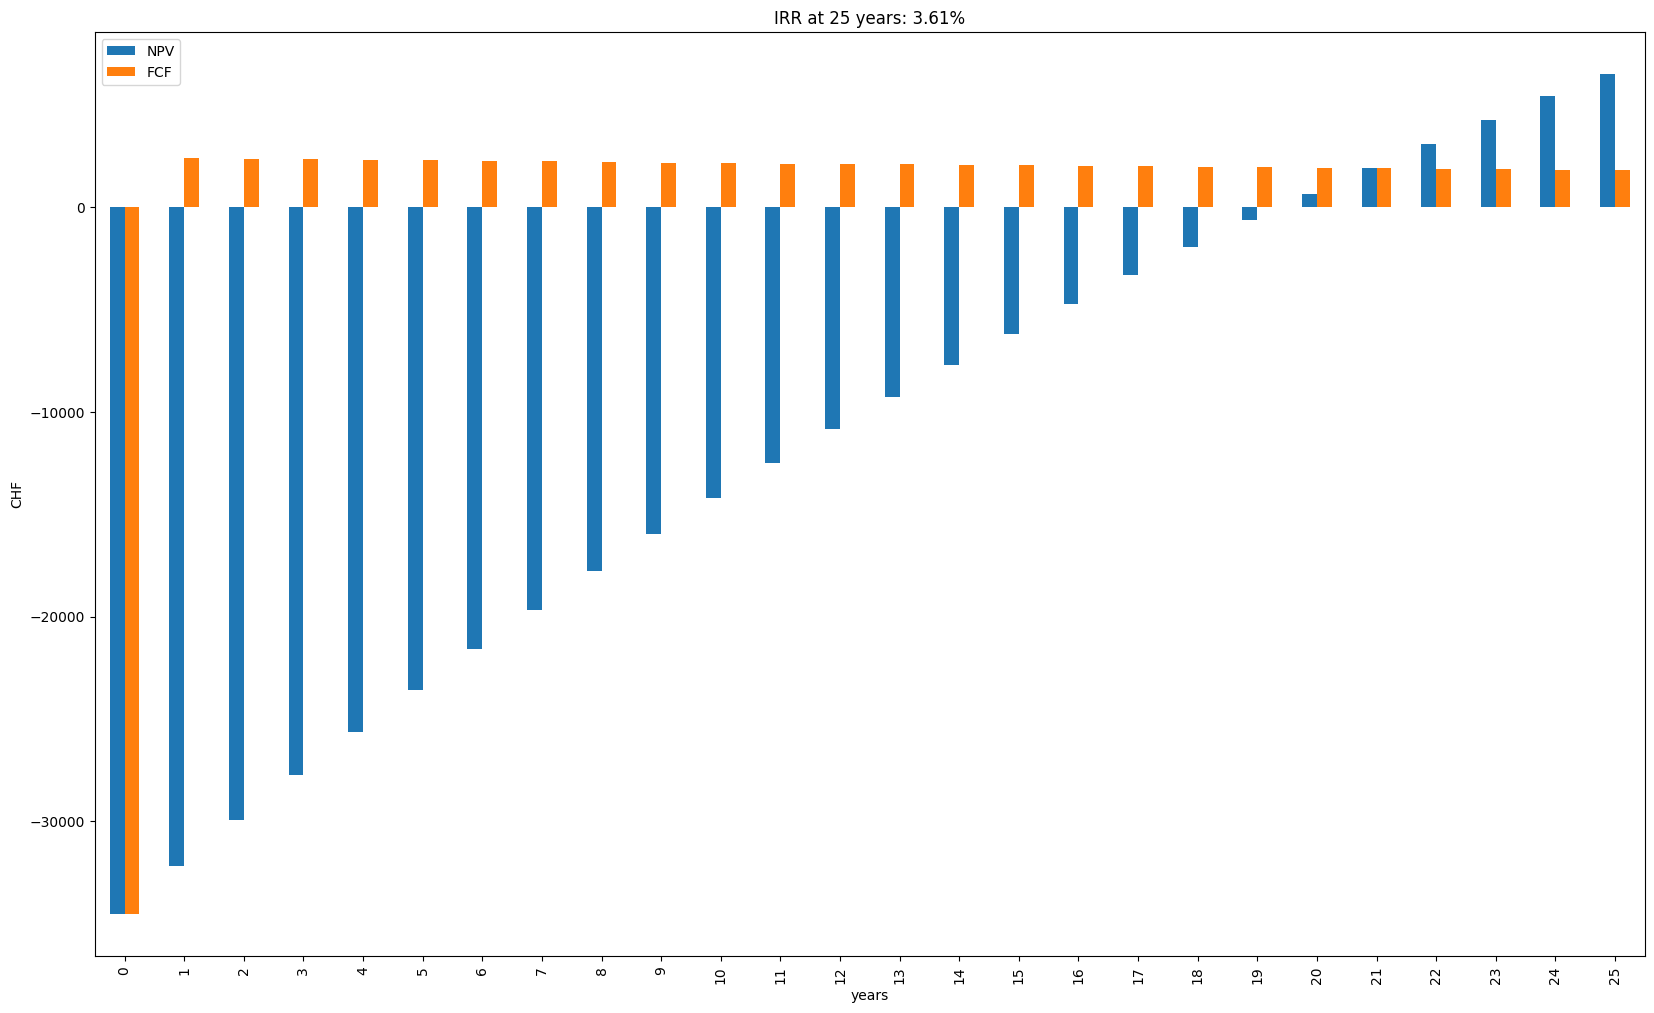

In [36]:
years = range(life_span)
capex = plant_cost
opex = np.ones(life_span) * o_and_m * plant_size
costi = np.hstack([capex, opex])

yearly_production = np.sum(np.reshape(e_ls, (life_span, -1)), axis=1)
revenues = yearly_production * p_pv

fcf = np.hstack([0, revenues]) - costi  # free cash flow
npv = np.array([npf.npv(wacc, fcf[:i]) for i in np.arange(1, life_span + 2)])
irr = npf.irr(fcf)

financials = pd.DataFrame(data={'years': np.arange(26), 'NPV': npv, 'FCF': fcf}).set_index('years')

fig, ax = plt.subplots(1,1,figsize=(20,12))
financials.plot(kind='bar', title='IRR at {} years: {:.2%}'.format(life_span, irr), ax=ax).set_ylabel('CHF');